# Expanded Variance Model for Effective Sample Size (ESS)

This notebook develops, simulates, and reports the expanded Effective Sample Size (ESS) variance model for near-infrared (NIR) and pharmaceutical PAT sampling contexts:

$$
\sigma_{\mathrm{obs}}^2 = \sigma_{\mathrm{floor}}^2 + \frac{k}{\mathrm{ESS}^{b}}
$$

The central message is that increasing ESS reduces the sampling component of analytical variance, but it cannot remove the irreducible variance imposed by analytical repeatability, instrument noise, model residual error, and other non-sampling terms. The notebook follows the reporting workflow used by the existing ESS notebooks: simulated tables and figures are generated reproducibly, figures are saved as high-resolution PNG files, tables are saved as CSV files, and a standalone Word report is exported using the repository reporting utilities.

## Scientific Background

Effective Sample Size is a practical bridge between physical sampling theory and optical PAT measurement design. In NIR analysis of powders, the numerical value of a spectrum is not determined only by the chemical concentration in the bulk lot. It is also influenced by how much material is optically interrogated, whether the interrogated particles are representative of the lot, how many independent particle configurations enter the measurement, and how much instrumental or chemometric noise remains after averaging.

For a heterogeneous particulate material, a small optical sampling volume may over-represent a local cluster of high- or low-concentration particles. Increasing the effective amount of independently sampled material reduces this random heterogeneity contribution. Real instruments also have repeatability limits: detector noise, lamp fluctuations, probe contact, optical scattering variation, model residuals, and reference-method uncertainty produce a residual variance that does not disappear merely because the optical sampling volume is made larger.

## Expanded Variance Equation

The model used throughout this notebook is:

$$
\sigma_{\mathrm{obs}}^2 = \sigma_{\mathrm{floor}}^2 + \frac{k}{\mathrm{ESS}^{b}}
$$

For ideal independent sampling, variance is expected to scale inversely with the effective number or mass of independent increments:

$$
\sigma^2 \propto \frac{1}{\mathrm{ESS}}
$$

Taking the square root gives the standard deviation relationship:

$$
\sigma \propto \frac{1}{\sqrt{\mathrm{ESS}}}
$$

The square-root relationship is why very large increases in sampled mass are required to obtain modest improvements once the system is already in the low-variance region.

## Physical Meaning of All Variables

| Symbol | Meaning | Physical meaning | Unit |
|---|---|---|---|
| $\sigma_{\mathrm{obs}}^2$ | Observed variance | Total measured variance of repeated predictions or assays | $(\mathrm{mg/g})^2$ |
| $\sigma_{\mathrm{obs}}$ | Observed standard deviation | Repeatability expressed on the concentration scale | $\mathrm{mg/g}$ |
| $\sigma_{\mathrm{floor}}^2$ | Irreducible variance floor | Residual variance from repeatability, instrument noise, model error, and other non-sampling effects | $(\mathrm{mg/g})^2$ |
| $\sigma_{\mathrm{floor}}$ | Irreducible standard deviation floor | Minimum attainable standard deviation under the model | $\mathrm{mg/g}$ |
| $\mathrm{ESS}$ | Effective Sample Size | Effective independently represented sample mass or equivalent sampled material basis | $\mathrm{mg}$ |
| $k$ | Sampling heterogeneity constant | Scale factor for variance generated by particulate heterogeneity at low ESS | variable, commonly $(\mathrm{mg/g})^2\,\mathrm{mg}^{b}$ |
| $b$ | ESS exponent | Describes how efficiently variance decreases as ESS increases | dimensionless |
| $\sigma_{\mathrm{sampling}}^2$ | Sampling variance | Variance contribution from finite powder representativity | $(\mathrm{mg/g})^2$ |
| $\sigma_{\mathrm{instrument}}^2$ | Instrument variance | Variance contribution from spectral or instrumental repeatability | $(\mathrm{mg/g})^2$ |
| $n_{\mathrm{scan}}$ | Number of sub-scans | Number of spectra or sub-scans averaged into one analytical result | count |

## Connection to Theory of Sampling (Gy)

Pierre Gy's Theory of Sampling states that sampling error is controlled by the interaction between material heterogeneity and the sampling process. For particulate systems, the Fundamental Sampling Error decreases when a larger and more representative mass is collected, provided that increments are selected with correct probabilistic sampling principles and sufficiently independent particle inclusion.

The ESS model is not a full Gy equation. It is a compact empirical and mechanistic approximation that carries the same central scaling idea: increasing the effective number of independently represented particles reduces sampling variance. In the idealized limit where each increment is independent and identically distributed:

$$
\mathrm{Var}(\bar{x}) = \frac{\sigma_{\mathrm{particle}}^2}{n}
$$

If effective sample mass is proportional to the number of independent particle-scale increments, then:

$$
n \propto \mathrm{ESS}
$$

and therefore:

$$
\mathrm{Var}(\bar{x}) \propto \frac{1}{\mathrm{ESS}}
$$

This is the theoretical basis for expecting $b \approx 1$ in an ideal independent sampling regime. Deviations from $b=1$ indicate non-ideal representativity, correlated increments, segregation, flow structure, optical re-sampling of the same particles, or other departures from ideal sampling conditions.

## Variance Floor and NIR Repeatability

In real NIR measurement systems, the ESS-dependent sampling term is only one part of the total variance. Analytical repeatability imposes a floor:

$$
\lim_{\mathrm{ESS}\to\infty}\sigma_{\mathrm{obs}}^2 = \sigma_{\mathrm{floor}}^2
$$

The associated standard deviation limit is:

$$
\lim_{\mathrm{ESS}\to\infty}\sigma_{\mathrm{obs}} = \sigma_{\mathrm{floor}}
$$

This means that a measurement can be sampling-limited at low ESS and repeatability-limited at high ESS. Once the sampling term is small relative to $\sigma_{\mathrm{floor}}^2$, further increases in ESS have little practical effect on observed repeatability.

## Role of Effective Sample Size

ESS should be interpreted as an effective quantity, not merely a geometric volume or nominal mass. Two setups may have the same nominal mass in the optical field but different ESS if one system repeatedly observes the same particles while another system exposes fresh, independent material.

A useful decomposition is:

$$
\sigma_{\mathrm{total}}^2 = \sigma_{\mathrm{sampling}}^2 + \sigma_{\mathrm{instrument}}^2
$$

Increasing powder representativity primarily reduces $\sigma_{\mathrm{sampling}}^2$. Increasing spectral averaging primarily reduces $\sigma_{\mathrm{instrument}}^2$. A flowing system can reduce both if each additional scan observes fresh powder and also contributes to spectral averaging.

## Meaning of the Exponent b

The exponent $b$ controls how efficiently variance decreases with increasing ESS:

$$
\sigma_{\mathrm{sampling}}^2 = \frac{k}{\mathrm{ESS}^{b}}
$$

When $b \approx 1$, the system behaves like ideal independent averaging. Each proportional increase in ESS produces the theoretically expected proportional reduction in sampling variance. When $b < 1$, increasing ESS is less effective than ideal, often because scans are correlated, the same material is repeatedly sampled, segregation persists, or the optical geometry does not add independent increments efficiently. When $b > 1$, variance decreases faster than ideal over the modeled region, which may occur in a limited range if a design change improves both mass and independence, though such behavior should be interpreted cautiously.

## Two Different Routes for Increasing ESS

There are two physically different routes that are often both described as increasing ESS:

1. Increasing powder representativity by exposing more independent material to the measurement.
2. Increasing spectral averaging by collecting more sub-scans from the same or similar material configuration.

These routes are not physically equivalent. Powder representativity changes the particulate sampling basis. Spectral averaging improves instrumental precision, but if it repeatedly observes the same static particle arrangement it may not reduce the sampling error caused by local heterogeneity.

## Static versus Flowing Powder Systems

Static and flowing powder systems behave differently because the independence structure is different. In a static powder system, additional sub-scans may mainly reduce instrumental noise:

$$
\sigma_{\mathrm{instrument}}^2(n_{\mathrm{scan}}) = \frac{\sigma_{\mathrm{instrument},0}^2}{n_{\mathrm{scan}}}
$$

but the powder sampling term can remain nearly constant if the same particles stay in the optical field:

$$
\sigma_{\mathrm{sampling}}^2 \approx \mathrm{constant}
$$

In a flowing powder system, additional acquisition time can expose more independent material and reduce both terms:

$$
\sigma_{\mathrm{sampling}}^2(\mathrm{ESS}) = \frac{k}{\mathrm{ESS}^{b}}
$$

$$
\sigma_{\mathrm{instrument}}^2(n_{\mathrm{scan}}) = \frac{\sigma_{\mathrm{instrument},0}^2}{n_{\mathrm{scan}}}
$$

This is why flowing systems may show stronger repeatability gains with acquisition time than static systems, provided that flow is stable and representative.

## Simulation Framework

The simulations below use only `numpy`, `pandas`, and `matplotlib`. They implement the expanded variance model and save each figure as a high-resolution PNG in `results/expanded_variance_model/`. Tables are saved as CSV files in the same results folder and again in the timestamped report folder during export.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_FILENAME = "expanded_variance_model_ESS.ipynb"
SETUP_NAME = "expanded_variance_model"
REPORT_FILENAME = "expanded_variance_model_ESS_report.docx"
REPORT_MARKDOWN_FILENAME = Path(REPORT_FILENAME).with_suffix(".md").name

notebook_file = globals().get("__vsc_ipynb_file__")
if notebook_file:
    PROJECT_ROOT = Path(notebook_file).resolve().parent.parent
else:
    cwd = Path.cwd().resolve()
    if (cwd / "notebooks" / NOTEBOOK_FILENAME).exists():
        PROJECT_ROOT = cwd
    elif cwd.name == "notebooks" and (cwd / NOTEBOOK_FILENAME).exists():
        PROJECT_ROOT = cwd.parent
    else:
        PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

NOTEBOOK_PATH = PROJECT_ROOT / "notebooks" / NOTEBOOK_FILENAME
RESULTS_DIR = PROJECT_ROOT / "results" / SETUP_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.figsize": (8.5, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.30,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COLOR_OBS = "#1f77b4"
COLOR_VAR = "#2ca02c"
COLOR_FLOOR = "#d62728"
COLOR_ALT = "#9467bd"

In [2]:
# Parameter section
ESS_VALUES = np.arange(1, 1001, dtype=float)
SIGMA_FLOOR_VARIANCE = 0.16
SIGMA_FLOOR = np.sqrt(SIGMA_FLOOR_VARIANCE)
K_SAMPLING = 36.0
B_IDEAL = 1.0

B_VALUES = [0.5, 1.0, 1.5]
SIGMA_FLOOR_VALUES = [0.1, 0.3, 0.5]
PRACTICAL_ESS_VALUES = [10, 100, 1000]

In [3]:
def calculate_variance(ess: np.ndarray | float, sigma_floor_variance: float, k: float, b: float) -> np.ndarray:
    """Calculate observed variance using the expanded ESS variance model."""
    ess_array = np.asarray(ess, dtype=float)
    if np.any(ess_array <= 0):
        raise ValueError("ESS values must be strictly positive.")
    if sigma_floor_variance < 0:
        raise ValueError("Variance floor must be non-negative.")
    if k < 0:
        raise ValueError("The heterogeneity constant k must be non-negative.")
    if b <= 0:
        raise ValueError("The ESS exponent b must be strictly positive.")
    return sigma_floor_variance + k / np.power(ess_array, b)


def calculate_sd(ess: np.ndarray | float, sigma_floor_variance: float, k: float, b: float) -> np.ndarray:
    """Calculate observed standard deviation from the expanded ESS variance model."""
    return np.sqrt(calculate_variance(ess, sigma_floor_variance, k, b))


def simulate_ESS_response(ess_values: np.ndarray, sigma_floor_variance: float, k: float, b: float) -> pd.DataFrame:
    """Simulate variance and standard deviation over a vector of ESS values."""
    variance = calculate_variance(ess_values, sigma_floor_variance, k, b)
    return pd.DataFrame(
        {
            "ESS_mg": ess_values,
            "sigma_floor_variance_mg_g_sq": sigma_floor_variance,
            "k": k,
            "b": b,
            "observed_variance_mg_g_sq": variance,
            "observed_sd_mg_g": np.sqrt(variance),
        }
    )


def save_figure(fig: plt.Figure, filename: str, output_dir: Path = RESULTS_DIR, dpi: int = 300) -> Path:
    """Save a matplotlib figure as a high-resolution PNG using the notebook convention."""
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    return output_path


def save_table(df: pd.DataFrame, filename: str, output_dir: Path = RESULTS_DIR) -> Path:
    """Save a table as UTF-8 CSV in the results folder."""
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / filename
    df.to_csv(output_path, index=False, encoding="utf-8")
    return output_path

## Simulation Results

The following simulations progressively isolate the effect of ESS, the exponent $b$, the variance floor, and the distinction between powder representativity and spectral averaging.

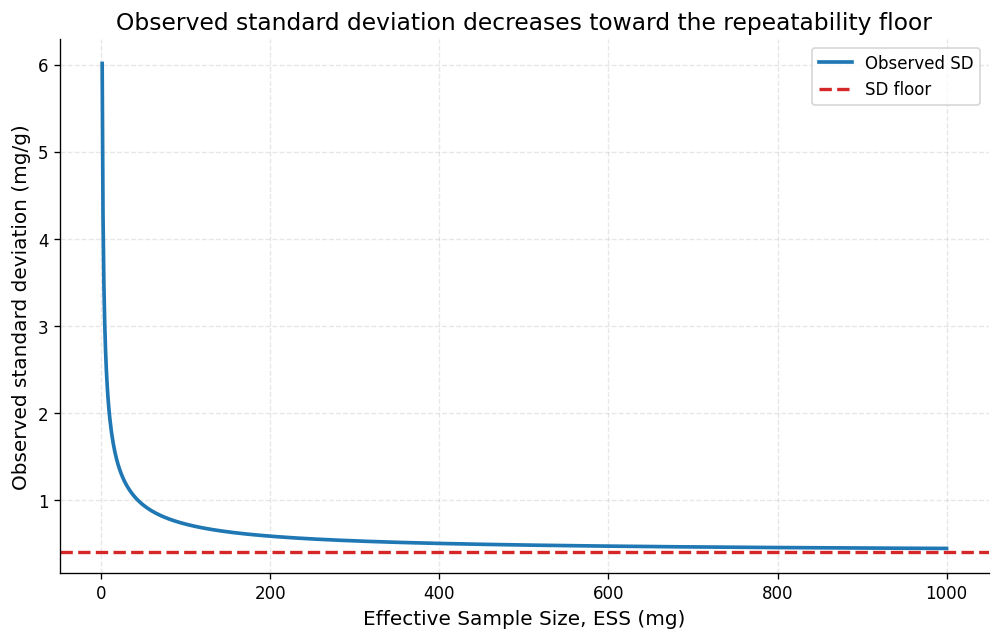

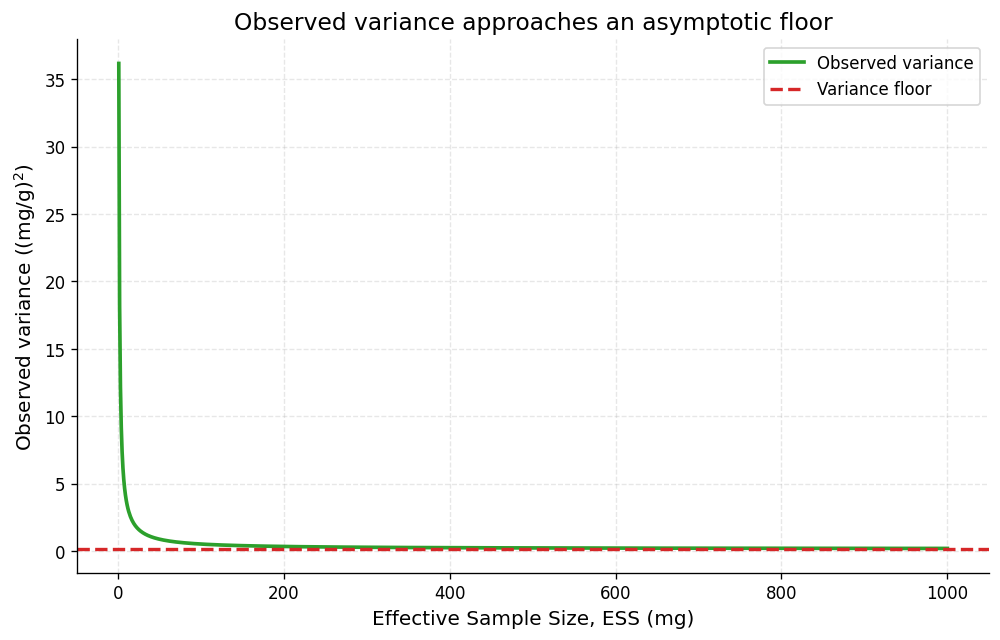

In [4]:
# Simulation 1: variance reduction with increasing ESS
sim1_df = simulate_ESS_response(ESS_VALUES, SIGMA_FLOOR_VARIANCE, K_SAMPLING, B_IDEAL)
save_table(sim1_df, "simulation_01_ess_response.csv")

fig_sim1_sd, ax = plt.subplots()
ax.plot(sim1_df["ESS_mg"], sim1_df["observed_sd_mg_g"], color=COLOR_OBS, linewidth=2.2, label="Observed SD")
ax.axhline(SIGMA_FLOOR, color=COLOR_FLOOR, linestyle="--", linewidth=2.0, label="SD floor")
ax.set_title("Observed standard deviation decreases toward the repeatability floor")
ax.set_xlabel("Effective Sample Size, ESS (mg)")
ax.set_ylabel("Observed standard deviation (mg/g)")
ax.legend()
fig_sim1_sd.tight_layout()
plot_01_path = save_figure(fig_sim1_sd, "plot_01_observed_sd_vs_ESS.png")
plt.show()

fig_sim1_var, ax = plt.subplots()
ax.plot(sim1_df["ESS_mg"], sim1_df["observed_variance_mg_g_sq"], color=COLOR_VAR, linewidth=2.2, label="Observed variance")
ax.axhline(SIGMA_FLOOR_VARIANCE, color=COLOR_FLOOR, linestyle="--", linewidth=2.0, label="Variance floor")
ax.set_title("Observed variance approaches an asymptotic floor")
ax.set_xlabel("Effective Sample Size, ESS (mg)")
ax.set_ylabel("Observed variance ((mg/g)$^2$)")
ax.legend()
fig_sim1_var.tight_layout()
plot_02_path = save_figure(fig_sim1_var, "plot_02_observed_variance_vs_ESS.png")
plt.show()

Simulation 1 shows the defining behavior of the expanded model. At low ESS, the heterogeneity term $k/\mathrm{ESS}^{b}$ dominates the observed variance. At high ESS, the sampling term becomes small and the observed variance approaches $\sigma_{\mathrm{floor}}^2$.

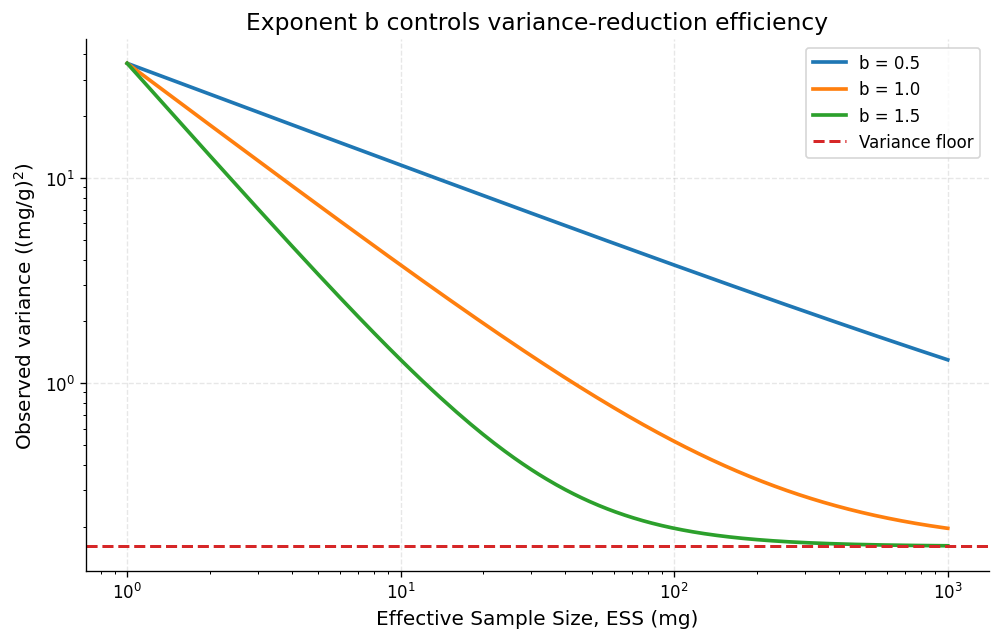

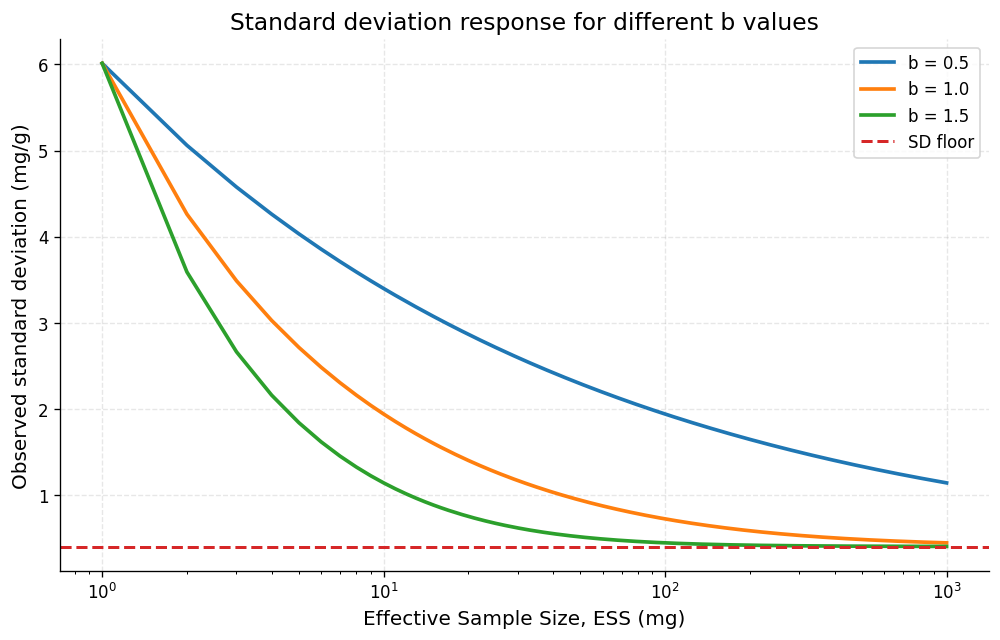

In [5]:
# Simulation 2: compare different b values
sim2_frames = [simulate_ESS_response(ESS_VALUES, SIGMA_FLOOR_VARIANCE, K_SAMPLING, b) for b in B_VALUES]
sim2_df = pd.concat(sim2_frames, ignore_index=True)
save_table(sim2_df, "simulation_02_b_sensitivity.csv")

fig_sim2_var, ax = plt.subplots()
for b in B_VALUES:
    subset = sim2_df[sim2_df["b"] == b]
    ax.plot(subset["ESS_mg"], subset["observed_variance_mg_g_sq"], linewidth=2.2, label=f"b = {b:.1f}")
ax.axhline(SIGMA_FLOOR_VARIANCE, color=COLOR_FLOOR, linestyle="--", linewidth=1.8, label="Variance floor")
ax.set_title("Exponent b controls variance-reduction efficiency")
ax.set_xlabel("Effective Sample Size, ESS (mg)")
ax.set_ylabel("Observed variance ((mg/g)$^2$)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
fig_sim2_var.tight_layout()
plot_03_path = save_figure(fig_sim2_var, "plot_03_variance_vs_ESS_by_b.png")
plt.show()

fig_sim2_sd, ax = plt.subplots()
for b in B_VALUES:
    subset = sim2_df[sim2_df["b"] == b]
    ax.plot(subset["ESS_mg"], subset["observed_sd_mg_g"], linewidth=2.2, label=f"b = {b:.1f}")
ax.axhline(SIGMA_FLOOR, color=COLOR_FLOOR, linestyle="--", linewidth=1.8, label="SD floor")
ax.set_title("Standard deviation response for different b values")
ax.set_xlabel("Effective Sample Size, ESS (mg)")
ax.set_ylabel("Observed standard deviation (mg/g)")
ax.set_xscale("log")
ax.legend()
fig_sim2_sd.tight_layout()
plot_04_path = save_figure(fig_sim2_sd, "plot_04_sd_vs_ESS_by_b.png")
plt.show()

When $b=0.5$, ESS gains are inefficient; the system behaves as if additional material is only partly independent. When $b=1.0$, the variance follows the ideal independent sampling expectation. When $b=1.5$, variance decreases faster over this range, which may indicate that a design change is increasing both mass and independence.

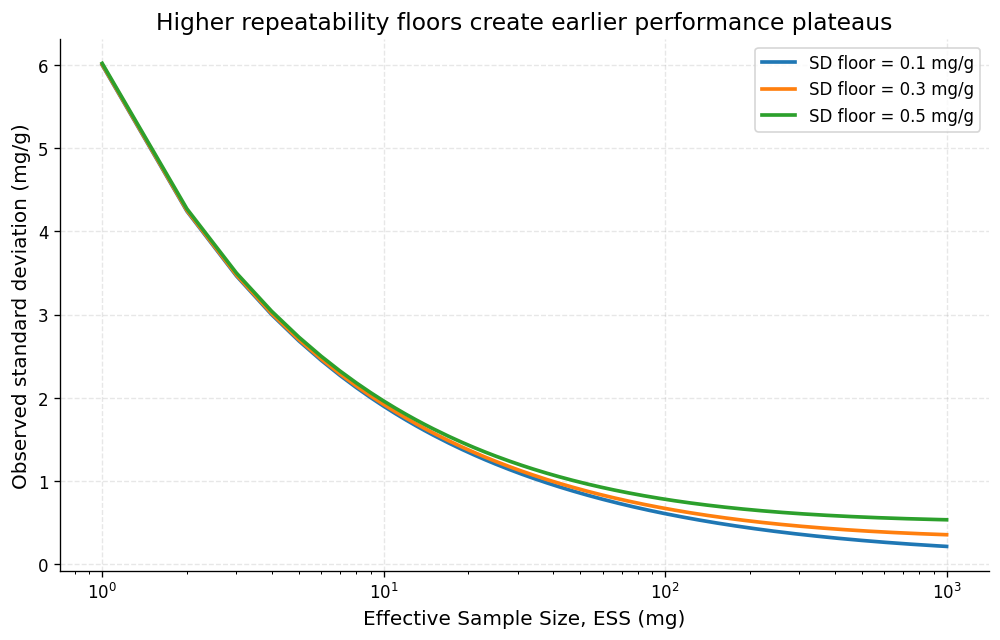

In [6]:
# Simulation 3: effect of changing the variance floor
sim3_frames = []
for sigma_floor in SIGMA_FLOOR_VALUES:
    df = simulate_ESS_response(ESS_VALUES, sigma_floor**2, K_SAMPLING, B_IDEAL)
    df["sigma_floor_mg_g"] = sigma_floor
    sim3_frames.append(df)
sim3_df = pd.concat(sim3_frames, ignore_index=True)
save_table(sim3_df, "simulation_03_variance_floor_sensitivity.csv")

fig_sim3_floor, ax = plt.subplots()
for sigma_floor in SIGMA_FLOOR_VALUES:
    subset = sim3_df[sim3_df["sigma_floor_mg_g"] == sigma_floor]
    ax.plot(subset["ESS_mg"], subset["observed_sd_mg_g"], linewidth=2.2, label=f"SD floor = {sigma_floor:.1f} mg/g")
ax.set_title("Higher repeatability floors create earlier performance plateaus")
ax.set_xlabel("Effective Sample Size, ESS (mg)")
ax.set_ylabel("Observed standard deviation (mg/g)")
ax.set_xscale("log")
ax.legend()
fig_sim3_floor.tight_layout()
plot_05_path = save_figure(fig_sim3_floor, "plot_05_sd_vs_ESS_by_variance_floor.png")
plt.show()

Simulation 3 demonstrates that improving powder representativity cannot overcome a poor analytical repeatability floor. A method with a high $\sigma_{\mathrm{floor}}$ reaches a plateau earlier and at a worse repeatability level than a method with a lower floor.

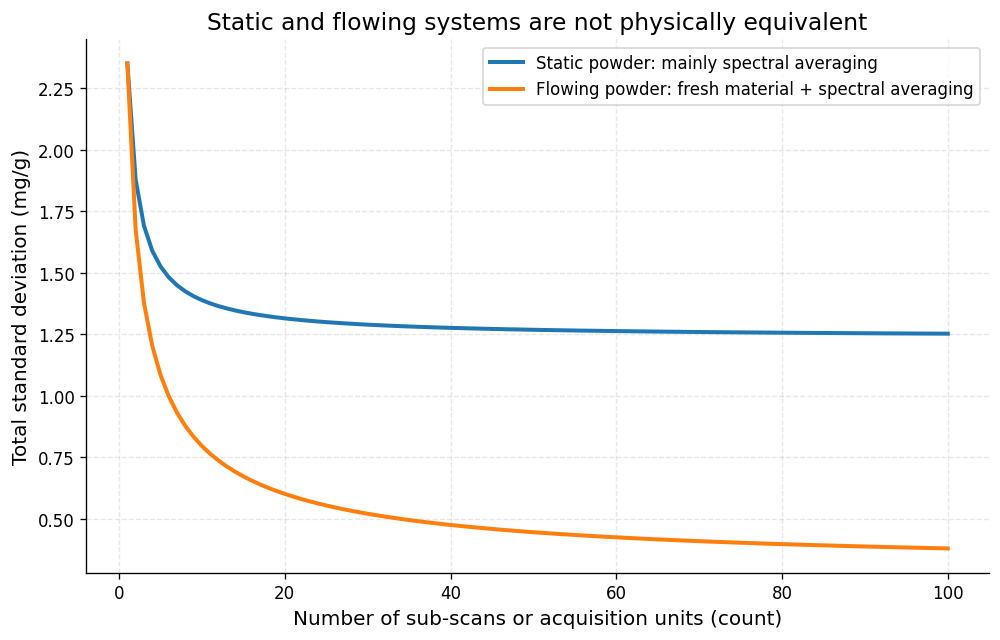

In [7]:
# Simulation 4: powder representativity versus spectral averaging
scan_counts = np.arange(1, 101, dtype=float)
static_ess_mg = np.full_like(scan_counts, 25.0)
flowing_ess_mg = 25.0 * scan_counts
instrument_variance_initial = 4.0
sampling_k = 36.0
sampling_b = 1.0
instrument_floor_variance = 0.09

static_sampling_variance = sampling_k / static_ess_mg**sampling_b
static_instrument_variance = instrument_floor_variance + instrument_variance_initial / scan_counts
static_total_variance = static_sampling_variance + static_instrument_variance

flowing_sampling_variance = sampling_k / flowing_ess_mg**sampling_b
flowing_instrument_variance = instrument_floor_variance + instrument_variance_initial / scan_counts
flowing_total_variance = flowing_sampling_variance + flowing_instrument_variance

sim4_df = pd.DataFrame(
    {
        "n_scan": scan_counts.astype(int),
        "static_ESS_mg": static_ess_mg,
        "flowing_ESS_mg": flowing_ess_mg,
        "static_sampling_variance_mg_g_sq": static_sampling_variance,
        "static_instrument_variance_mg_g_sq": static_instrument_variance,
        "static_total_variance_mg_g_sq": static_total_variance,
        "static_total_sd_mg_g": np.sqrt(static_total_variance),
        "flowing_sampling_variance_mg_g_sq": flowing_sampling_variance,
        "flowing_instrument_variance_mg_g_sq": flowing_instrument_variance,
        "flowing_total_variance_mg_g_sq": flowing_total_variance,
        "flowing_total_sd_mg_g": np.sqrt(flowing_total_variance),
    }
)
save_table(sim4_df, "simulation_04_static_vs_flowing.csv")

fig_sim4_static_flowing, ax = plt.subplots()
ax.plot(sim4_df["n_scan"], sim4_df["static_total_sd_mg_g"], linewidth=2.4, label="Static powder: mainly spectral averaging")
ax.plot(sim4_df["n_scan"], sim4_df["flowing_total_sd_mg_g"], linewidth=2.4, label="Flowing powder: fresh material + spectral averaging")
ax.set_title("Static and flowing systems are not physically equivalent")
ax.set_xlabel("Number of sub-scans or acquisition units (count)")
ax.set_ylabel("Total standard deviation (mg/g)")
ax.legend()
fig_sim4_static_flowing.tight_layout()
plot_06_path = save_figure(fig_sim4_static_flowing, "plot_06_static_vs_flowing_powder_systems.png")
plt.show()

Simulation 4 separates two mechanisms. In the static case, sampling variance remains high because additional scans mostly re-observe the same powder configuration. In the flowing case, additional acquisition time is assumed to introduce fresh material, so both the sampling component and the instrumental component decrease.

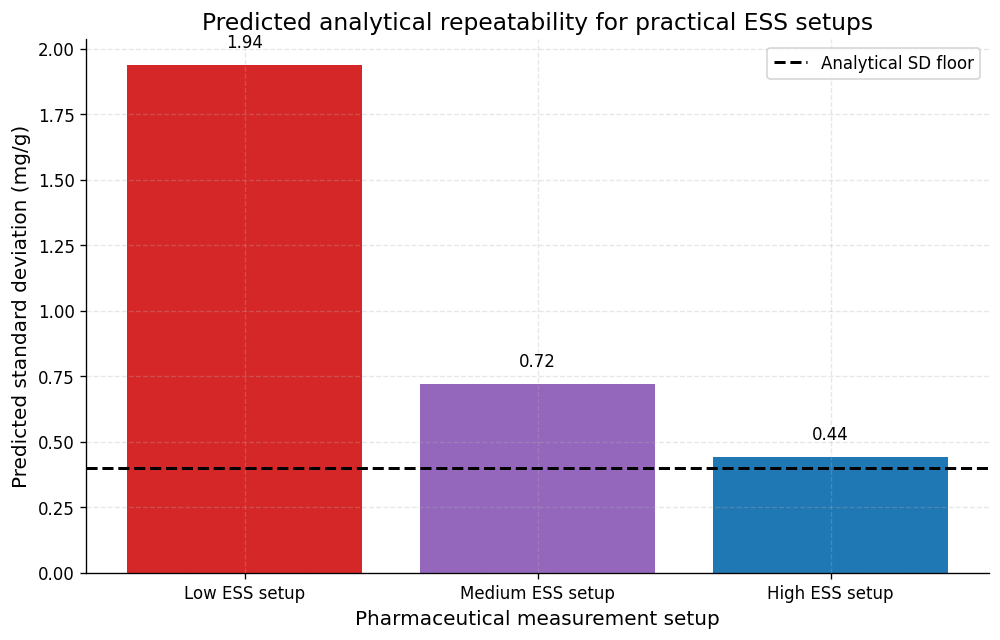

,setup,ESS_mg,observed_variance_mg_g_sq,observed_sd_mg_g,interpretation
0,Low ESS setup,10,3.760,1.939,Sampling-limited; local heterogeneity dominate...
1,Medium ESS setup,100,0.520,0.721,Transition region; both sampling and floor are...
2,High ESS setup,1000,0.196,0.443,Near floor-limited; further ESS gains have dim...


In [8]:
# Simulation 5: practical pharmaceutical example
practical_labels = ["Low ESS setup", "Medium ESS setup", "High ESS setup"]
practical_df = simulate_ESS_response(np.asarray(PRACTICAL_ESS_VALUES, dtype=float), SIGMA_FLOOR_VARIANCE, K_SAMPLING, B_IDEAL)
practical_df.insert(0, "setup", practical_labels)
practical_df["interpretation"] = [
    "Sampling-limited; local heterogeneity dominates repeatability.",
    "Transition region; both sampling and floor are important.",
    "Near floor-limited; further ESS gains have diminishing returns.",
]
save_table(practical_df, "simulation_05_practical_pharmaceutical_example.csv")

fig_sim5_practical, ax = plt.subplots()
bars = ax.bar(practical_df["setup"], practical_df["observed_sd_mg_g"], color=[COLOR_FLOOR, COLOR_ALT, COLOR_OBS])
ax.axhline(SIGMA_FLOOR, color="black", linestyle="--", linewidth=1.8, label="Analytical SD floor")
ax.set_title("Predicted analytical repeatability for practical ESS setups")
ax.set_xlabel("Pharmaceutical measurement setup")
ax.set_ylabel("Predicted standard deviation (mg/g)")
ax.legend()
for bar, value in zip(bars, practical_df["observed_sd_mg_g"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.05, f"{value:.2f}", ha="center", va="bottom", fontsize=10)
fig_sim5_practical.tight_layout()
plot_07_path = save_figure(fig_sim5_practical, "plot_07_practical_pharmaceutical_example.png")
plt.show()

practical_display_df = practical_df[
    ["setup", "ESS_mg", "observed_variance_mg_g_sq", "observed_sd_mg_g", "interpretation"]
].copy()
practical_display_df["ESS_mg"] = practical_display_df["ESS_mg"].map("{:.0f}".format)
practical_display_df["observed_variance_mg_g_sq"] = practical_display_df["observed_variance_mg_g_sq"].map("{:.3f}".format)
practical_display_df["observed_sd_mg_g"] = practical_display_df["observed_sd_mg_g"].map("{:.3f}".format)
practical_display_df

The practical example illustrates diminishing returns. Moving from low ESS to medium ESS gives a large repeatability improvement. Moving from medium ESS to high ESS still helps, but the gain is smaller because the analytical floor becomes a larger fraction of total variance.

## Sensitivity Analysis

The sensitivity analysis has two main conclusions. First, the exponent $b$ is a physically meaningful diagnostic, not just a curve-fitting coefficient. It reveals whether added ESS behaves like independent sampling. Second, the variance floor determines the best achievable precision.

The transition between sampling-limited and floor-limited behavior occurs approximately when:

$$
\frac{k}{\mathrm{ESS}^{b}} \approx \sigma_{\mathrm{floor}}^2
$$

Solving for ESS gives a characteristic transition scale:

$$
\mathrm{ESS}_{\mathrm{transition}} \approx \left(\frac{k}{\sigma_{\mathrm{floor}}^2}\right)^{1/b}
$$

Below this scale, increasing ESS is highly valuable. Above this scale, observed variance is increasingly controlled by the floor.

In [9]:
transition_ess = (K_SAMPLING / SIGMA_FLOOR_VARIANCE) ** (1.0 / B_IDEAL)
sensitivity_summary_df = pd.DataFrame(
    [
        {"Quantity": "Variance floor", "Value": f"{SIGMA_FLOOR_VARIANCE:.3f}", "Unit": "(mg/g)^2"},
        {"Quantity": "SD floor", "Value": f"{SIGMA_FLOOR:.3f}", "Unit": "mg/g"},
        {"Quantity": "Sampling heterogeneity constant k", "Value": f"{K_SAMPLING:.3f}", "Unit": "(mg/g)^2 mg^b"},
        {"Quantity": "ESS exponent", "Value": f"{B_IDEAL:.3f}", "Unit": "dimensionless"},
        {"Quantity": "Approximate transition ESS", "Value": f"{transition_ess:.1f}", "Unit": "mg"},
    ]
)
save_table(sensitivity_summary_df, "sensitivity_summary.csv")
sensitivity_summary_df

,Quantity,Value,Unit
0,Variance floor,0.160,(mg/g)^2
1,SD floor,0.400,mg/g
2,Sampling heterogeneity constant k,36.000,(mg/g)^2 mg^b
3,ESS exponent,1.000,dimensionless
4,Approximate transition ESS,225.0,mg


## Practical Implications for PAT

For PAT method development, the expanded ESS variance model encourages a disciplined separation between sampling representativity and analytical repeatability. Increasing the number of spectra is valuable, but it is not automatically equivalent to increasing powder representativity.

A robust PAT strategy should evaluate:

- whether powder motion brings fresh material into the optical sampling zone;
- whether flow rate, acquisition time, and probe geometry jointly determine ESS;
- whether the observed exponent $b$ is close to the independent-sampling expectation;
- whether the method has reached a repeatability floor where further ESS increases have little effect;
- whether static validation measurements understate or overstate the repeatability expected in a flowing process.

## Summary

The expanded ESS variance equation provides a compact model for understanding repeatability in NIR and PAT powder measurements:

$$
\sigma_{\mathrm{obs}}^2 = \sigma_{\mathrm{floor}}^2 + \frac{k}{\mathrm{ESS}^{b}}
$$

The model separates irreducible analytical variance from sampling variance. It explains why increasing ESS improves repeatability at low ESS, why improvements eventually plateau, and why the exponent $b$ carries physical information about sampling independence. For ideal independent sampling, $b \approx 1$ is theoretically expected because variance decreases in proportion to the number or mass of independent increments.

## References

- Gy, P. *Sampling for Analytical Purposes*. Wiley, 1998.
- Pitard, F. F. *Pierre Gy's Sampling Theory and Sampling Practice*. CRC Press, 1993.
- Esbensen, K. H. *Introduction to the Theory and Practice of Sampling*. IM Publications Open, 2020.
- Esbensen, K. H., and Románach, R. J. Representative sampling for process analytical technology and near-infrared spectroscopy in pharmaceutical manufacturing.
- Esbensen, K. H., Paasch-Mortensen, P., and colleagues. Theory of Sampling contributions on representative sampling, heterogeneity, and process sampling.
- Journal of Near Infrared Spectroscopy articles on representative sampling, powder heterogeneity, and NIR process analysis.

In [10]:
# Word export and artifact organization
import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
build_structured_word_report_pandoc = reporting_utils.build_structured_word_report_pandoc
create_run_directory = reporting_utils.create_run_directory
dataframe_to_markdown_table = reporting_utils.dataframe_to_markdown_table
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

timestamp, run_dir = create_run_directory(PROJECT_ROOT, SETUP_NAME)

report_tables = {
    "simulation_01_ess_response": sim1_df,
    "simulation_02_b_sensitivity": sim2_df,
    "simulation_03_variance_floor_sensitivity": sim3_df,
    "simulation_04_static_vs_flowing": sim4_df,
    "simulation_05_practical_pharmaceutical_example": practical_df,
    "sensitivity_summary": sensitivity_summary_df,
}

report_figures = {
    "plot_01_observed_sd_vs_ESS": fig_sim1_sd,
    "plot_02_observed_variance_vs_ESS": fig_sim1_var,
    "plot_03_variance_vs_ESS_by_b": fig_sim2_var,
    "plot_04_sd_vs_ESS_by_b": fig_sim2_sd,
    "plot_05_sd_vs_ESS_by_variance_floor": fig_sim3_floor,
    "plot_06_static_vs_flowing_powder_systems": fig_sim4_static_flowing,
    "plot_07_practical_pharmaceutical_example": fig_sim5_practical,
}

csv_files = save_dataframes_dict(report_tables, run_dir)
png_files = save_figures_dict(report_figures, run_dir, dpi=300)

parameter_summary = {
    "ESS range (mg)": f"{ESS_VALUES.min():.0f} to {ESS_VALUES.max():.0f}",
    "Variance floor ((mg/g)^2)": SIGMA_FLOOR_VARIANCE,
    "SD floor (mg/g)": SIGMA_FLOOR,
    "Sampling heterogeneity constant k": K_SAMPLING,
    "Default exponent b": B_IDEAL,
    "b values compared": B_VALUES,
    "Variance-floor SD values compared (mg/g)": SIGMA_FLOOR_VALUES,
    "Results folder": str(RESULTS_DIR.relative_to(PROJECT_ROOT)),
}

metadata = {
    "setup_name": SETUP_NAME,
    "timestamp": timestamp,
    "notebook_filename": NOTEBOOK_FILENAME,
    "report_filename": REPORT_FILENAME,
    "report_layout": "structured_scientific_report_pandoc",
    "report_markdown_filename": REPORT_MARKDOWN_FILENAME,
    "equation_rendering": "Pandoc TeX math to Word OMML editable equations",
    "csv_files": csv_files,
    "png_files": png_files,
    "results_folder": str(RESULTS_DIR),
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

variable_table_report_df = pd.DataFrame(
    [
        {"Symbol": "sigma_obs^2", "Meaning": "Observed variance", "Unit": "(mg/g)^2"},
        {"Symbol": "sigma_floor^2", "Meaning": "Irreducible variance floor", "Unit": "(mg/g)^2"},
        {"Symbol": "ESS", "Meaning": "Effective sample size", "Unit": "mg"},
        {"Symbol": "k", "Meaning": "Sampling heterogeneity constant", "Unit": "(mg/g)^2 mg^b"},
        {"Symbol": "b", "Meaning": "ESS exponent", "Unit": "dimensionless"},
        {"Symbol": "n_scan", "Meaning": "Number of sub-scans", "Unit": "count"},
    ]
)

selected_practical_report_df = practical_df[
    ["setup", "ESS_mg", "observed_variance_mg_g_sq", "observed_sd_mg_g", "interpretation"]
].copy()
selected_practical_report_df["ESS_mg"] = selected_practical_report_df["ESS_mg"].map(lambda value: f"{value:.0f}")
selected_practical_report_df["observed_variance_mg_g_sq"] = selected_practical_report_df["observed_variance_mg_g_sq"].map(lambda value: f"{value:.3f}")
selected_practical_report_df["observed_sd_mg_g"] = selected_practical_report_df["observed_sd_mg_g"].map(lambda value: f"{value:.3f}")

executive_summary_text = (
    "This report explains and simulates the expanded ESS variance equation for PAT and NIR powder measurements. "
    "The model separates an irreducible analytical variance floor from an ESS-dependent sampling variance term, "
    "thereby clarifying why increased representativity improves repeatability at low ESS but eventually reaches a plateau."
)

figure_entries = [
    {"filename": "plot_01_observed_sd_vs_ESS.png", "caption": "Figure 1. Observed standard deviation decreases toward the analytical repeatability floor."},
    {"filename": "plot_02_observed_variance_vs_ESS.png", "caption": "Figure 2. Observed variance approaches the irreducible variance floor."},
    {"filename": "plot_03_variance_vs_ESS_by_b.png", "caption": "Figure 3. The ESS exponent b controls variance-reduction efficiency."},
    {"filename": "plot_04_sd_vs_ESS_by_b.png", "caption": "Figure 4. Standard deviation response for different b values."},
    {"filename": "plot_05_sd_vs_ESS_by_variance_floor.png", "caption": "Figure 5. Increasing variance floors create higher performance plateaus."},
    {"filename": "plot_06_static_vs_flowing_powder_systems.png", "caption": "Figure 6. Static and flowing powder systems differ because fresh material changes sampling variance."},
    {"filename": "plot_07_practical_pharmaceutical_example.png", "caption": "Figure 7. Practical pharmaceutical ESS scenarios and predicted analytical repeatability."},
]

report_sections = [
    {"source": "notebook", "heading": "## Scientific Background"},
    {"source": "notebook", "heading": "## Expanded Variance Equation"},
    {"source": "notebook", "heading": "## Physical Meaning of All Variables"},
    {"source": "notebook", "heading": "## Connection to Theory of Sampling (Gy)"},
    {"source": "notebook", "heading": "## Variance Floor and NIR Repeatability"},
    {"source": "notebook", "heading": "## Role of Effective Sample Size"},
    {"source": "notebook", "heading": "## Meaning of the Exponent b"},
    {"source": "notebook", "heading": "## Two Different Routes for Increasing ESS"},
    {"source": "notebook", "heading": "## Static versus Flowing Powder Systems"},
    {"source": "notebook", "heading": "## Simulation Framework"},
    {"source": "notebook", "heading": "## Simulation Results"},
    {
        "source": "content",
        "heading": "Simulation tables",
        "body": "Variable definitions used by the model:\n\n"
        + dataframe_to_markdown_table(variable_table_report_df)
        + "\n\nPractical pharmaceutical example:\n\n"
        + dataframe_to_markdown_table(selected_practical_report_df),
    },
    {"source": "content", "heading": "Figures", "body": "The figures below are saved as high-resolution PNG files and embedded in the report.", "figures": figure_entries},
    {"source": "notebook", "heading": "## Sensitivity Analysis"},
    {"source": "content", "heading": "Sensitivity summary table", "body": dataframe_to_markdown_table(sensitivity_summary_df)},
    {"source": "notebook", "heading": "## Practical Implications for PAT"},
    {"source": "notebook", "heading": "## Summary"},
    {"source": "notebook", "heading": "## References"},
]

word_report_path = None
report_error = None
try:
    word_report_path = build_structured_word_report_pandoc(
        report_title="Expanded Variance Model for Effective Sample Size (ESS)",
        setup_name=SETUP_NAME,
        timestamp=timestamp,
        run_dir=run_dir,
        notebook_path=NOTEBOOK_PATH,
        output_filename=REPORT_FILENAME,
        executive_summary_text=executive_summary_text,
        parameter_summary=parameter_summary,
        report_sections=report_sections,
        appendix_sections=None,
        csv_filenames=csv_files,
        figure_filenames=png_files,
        markdown_filename=REPORT_MARKDOWN_FILENAME,
    )
except Exception as exc:
    report_error = str(exc)
    try:
        word_report_path = build_word_report(
            report_title="Expanded Variance Model for Effective Sample Size (ESS)",
            setup_name=SETUP_NAME,
            timestamp=timestamp,
            run_dir=run_dir,
            notebook_path=NOTEBOOK_PATH,
            purpose_text=executive_summary_text,
            assumptions_text=(
                "Fallback report export was used because Pandoc failed. Equations in the fallback report are rendered "
                "with the repository matplotlib equation image renderer, not as editable Word equations."
            ),
            parameter_summary=parameter_summary,
            csv_filenames=csv_files,
            figure_filenames=png_files,
            output_filename=REPORT_FILENAME,
            content_sections=[],
        )
    except Exception as fallback_exc:
        report_error = f"Pandoc and fallback report export both failed: {exc}; fallback: {fallback_exc}"

print(f"Results folder: {RESULTS_DIR}")
print(f"Report run directory: {run_dir}")
print(f"Exported CSV files: {csv_files}")
print(f"Exported PNG files: {png_files}")
print(f"Markdown report source: {run_dir / REPORT_MARKDOWN_FILENAME}")
if word_report_path is not None:
    print(f"Word report: {word_report_path}")
if report_error:
    print(f"Report warning: {report_error}")


Results folder: C:\temp files\EFS\results\expanded_variance_model
Report run directory: C:\temp files\EFS\reports\expanded_variance_model\20260512_135145
Exported CSV files: ['simulation_01_ess_response.csv', 'simulation_02_b_sensitivity.csv', 'simulation_03_variance_floor_sensitivity.csv', 'simulation_04_static_vs_flowing.csv', 'simulation_05_practical_pharmaceutical_example.csv', 'sensitivity_summary.csv']
Exported PNG files: ['plot_01_observed_sd_vs_ESS.png', 'plot_02_observed_variance_vs_ESS.png', 'plot_03_variance_vs_ESS_by_b.png', 'plot_04_sd_vs_ESS_by_b.png', 'plot_05_sd_vs_ESS_by_variance_floor.png', 'plot_06_static_vs_flowing_powder_systems.png', 'plot_07_practical_pharmaceutical_example.png']
Markdown report source: C:\temp files\EFS\reports\expanded_variance_model\20260512_135145\expanded_variance_model_ESS_report.md
Word report: C:\temp files\EFS\reports\expanded_variance_model\20260512_135145\expanded_variance_model_ESS_report.docx
